Using device: cuda
Epoch 1: Train=79.22% | NPDD=87.73% | FER=46.22% || TL=0.439 | TeL=0.278
Epoch 2: Train=89.15% | NPDD=89.73% | FER=44.24% || TL=0.251 | TeL=0.233
Epoch 3: Train=90.93% | NPDD=90.60% | FER=45.60% || TL=0.209 | TeL=0.216
Epoch 4: Train=92.46% | NPDD=91.12% | FER=44.95% || TL=0.178 | TeL=0.209
Epoch 5: Train=93.33% | NPDD=90.28% | FER=45.70% || TL=0.163 | TeL=0.222
Epoch 6: Train=93.71% | NPDD=90.42% | FER=45.42% || TL=0.154 | TeL=0.226
Epoch 7: Train=94.37% | NPDD=91.20% | FER=46.40% || TL=0.139 | TeL=0.215
Early stopping triggered
Best model saved.

 FINAL FER TEST ACCURACY: 46.4 %


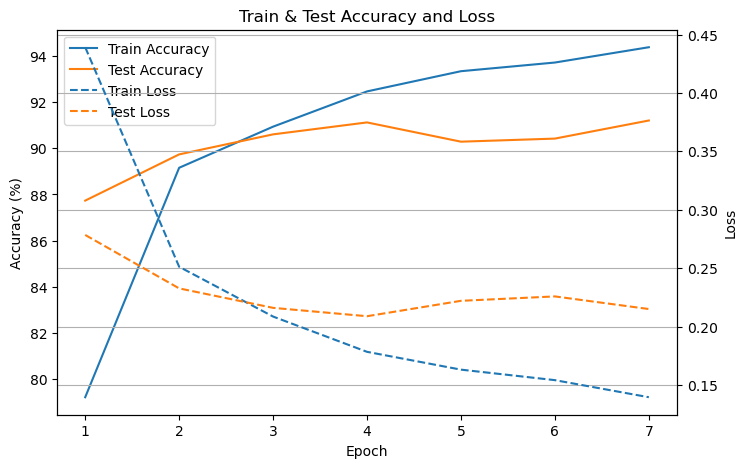

In [3]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt

# PATHS
DATA_DIR = "/home/student/Downloads/copycat_fer_project/npdd_sl"
TEST_DIR = "/home/student/Downloads/copycat_fer_project/FER2013_3 Class/test"
SAVE_PATH = "/home/student/Downloads/copycat_fer_project/copycat_model.pth"

# CONFIG
BATCH_SIZE = 64
EPOCHS = 30
LR = 1e-4   
NUM_CLASSES = 3
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("Using device:", DEVICE)

# TRANSFORM 
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

#  DATA 
full_ds = datasets.ImageFolder(DATA_DIR, transform=transform)

train_size = int(0.8 * len(full_ds))
test_size  = len(full_ds) - train_size

train_ds, npdd_test_ds = random_split(full_ds, [train_size, test_size])

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
npdd_test_loader = DataLoader(npdd_test_ds, batch_size=BATCH_SIZE, shuffle=False)

# FER TEST (REAL DATA)
fer_test_ds = datasets.ImageFolder(TEST_DIR, transform=transform)
fer_test_loader = DataLoader(fer_test_ds, batch_size=BATCH_SIZE, shuffle=False)

#  MODEL 
model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)

model.classifier = nn.Sequential(
    nn.Dropout(0.5),  
    nn.Linear(model.last_channel, NUM_CLASSES)
)

model = model.to(DEVICE)

# Freeze backbone
for param in model.features.parameters():
    param.requires_grad = False

# Unfreeze last layers
for param in model.features[-1].parameters():
    param.requires_grad = True
for param in model.features[-2].parameters():
    param.requires_grad = True
for param in model.features[-3].parameters():
    param.requires_grad = True

for param in model.classifier.parameters():
    param.requires_grad = True

# LOSS
criterion = nn.CrossEntropyLoss()

# OPTIMIZER
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR,
    weight_decay=5e-4
)

#  LR SCHEDULER
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)

# EARLY STOPPING
best_val_loss = float("inf")
patience = 3
counter = 0
delta = 0.002

train_acc_list = []
test_acc_list = []
train_loss_list = []
test_loss_list = []
fer_acc_list = []

# TRAINING
for epoch in range(EPOCHS):

    # TRAIN
    model.train()
    correct, total = 0, 0
    running_loss = 0

    for x, y in train_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)

        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        pred = out.argmax(1)
        correct += (pred == y).sum().item()
        total += y.size(0)

    train_acc = 100 * correct / total
    train_loss = running_loss / len(train_loader)

    train_acc_list.append(train_acc)
    train_loss_list.append(train_loss)

    #  NPDD TEST 
    model.eval()
    test_loss = 0
    test_correct, test_total = 0, 0

    with torch.no_grad():
        for x, y in npdd_test_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)

            out = model(x)
            loss = criterion(out, y)

            test_loss += loss.item()

            pred = out.argmax(1)
            test_correct += (pred == y).sum().item()
            test_total += y.size(0)

    test_loss /= len(npdd_test_loader)
    test_acc = 100 * test_correct / test_total

    test_acc_list.append(test_acc)
    test_loss_list.append(test_loss)

    #  FER TEST EVERY EPOCH 
    fer_correct, fer_total = 0, 0

    with torch.no_grad():
        for x, y in fer_test_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)

            out = model(x)
            pred = out.argmax(1)

            fer_correct += (pred == y).sum().item()
            fer_total += y.size(0)

    fer_acc = 100 * fer_correct / fer_total
    fer_acc_list.append(fer_acc)

    # PRINT
    print(f"Epoch {epoch+1}: "
          f"Train={train_acc:.2f}% | NPDD={test_acc:.2f}% | FER={fer_acc:.2f}% || "
          f"TL={train_loss:.3f} | TeL={test_loss:.3f}")

    # EARLY STOPPING
    if test_loss < best_val_loss - delta:
        best_val_loss = test_loss
        counter = 0
        torch.save(model.state_dict(), SAVE_PATH)
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping triggered")
            break

    scheduler.step()

print("Best model saved.")

#  FINAL FER EVALUATION 
print("\n FINAL FER TEST ACCURACY:", round(fer_acc_list[-1],2), "%")

# GRAPH 
epochs_range = range(1, len(train_acc_list)+1)

fig, ax1 = plt.subplots(figsize=(8,5))

ax1.set_xlabel("Epoch")
ax1.set_ylabel("Accuracy (%)")
ax1.plot(epochs_range, train_acc_list, label="Train Accuracy")
ax1.plot(epochs_range, test_acc_list, label="Test Accuracy")

ax2 = ax1.twinx()
ax2.set_ylabel("Loss")
ax2.plot(epochs_range, train_loss_list, linestyle='--', label="Train Loss")
ax2.plot(epochs_range, test_loss_list, linestyle='--', label="Test Loss")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(lines1 + lines2, labels1 + labels2, loc="best")

plt.title("Train & Test Accuracy and Loss")
plt.grid(True)
plt.show()

Using device: cuda
Epoch 1: Train=85.33% | NPDD=90.23% | FER=44.55% || TL=0.534 | TeL=0.461
Epoch 2: Train=91.61% | NPDD=90.90% | FER=46.57% || TL=0.445 | TeL=0.454
Epoch 3: Train=93.30% | NPDD=88.32% | FER=46.69% || TL=0.419 | TeL=0.487
Epoch 4: Train=94.66% | NPDD=88.95% | FER=45.84% || TL=0.399 | TeL=0.497
Epoch 5: Train=96.03% | NPDD=89.95% | FER=45.44% || TL=0.380 | TeL=0.476
Epoch 6: Train=96.87% | NPDD=90.55% | FER=44.85% || TL=0.368 | TeL=0.454
Epoch 7: Train=97.67% | NPDD=90.98% | FER=46.03% || TL=0.355 | TeL=0.456
Early stopping triggered
Best model saved.

 FINAL FER TEST ACCURACY: 46.03 %


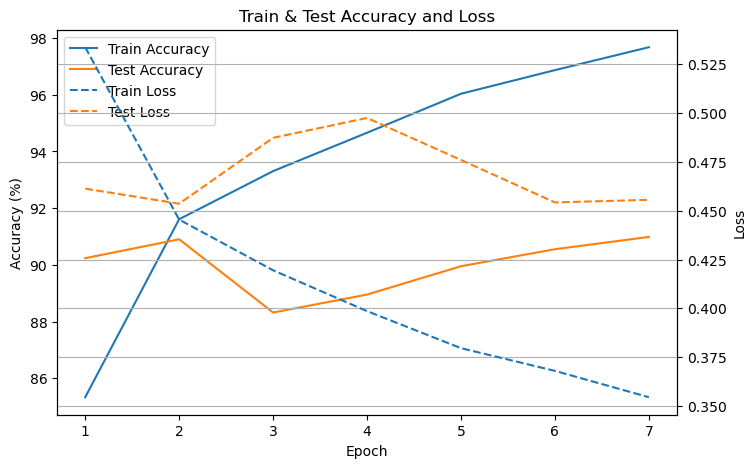

In [4]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt

# PATHS
DATA_DIR = "/home/student/Downloads/copycat_fer_project/npdd_sl"
TEST_DIR = "/home/student/Downloads/copycat_fer_project/FER2013_3 Class/test"
SAVE_PATH = "/home/student/Downloads/copycat_fer_project/copycat_model.pth"

# CONFIG
BATCH_SIZE = 64
EPOCHS = 25
LR = 3e-4
NUM_CLASSES = 3
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("Using device:", DEVICE)

# TRANSFORM (NO CHANGE)
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

# DATA
full_ds = datasets.ImageFolder(DATA_DIR, transform=transform)

train_size = int(0.8 * len(full_ds))
test_size  = len(full_ds) - train_size

train_ds, npdd_test_ds = random_split(full_ds, [train_size, test_size])

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
npdd_test_loader = DataLoader(npdd_test_ds, batch_size=BATCH_SIZE, shuffle=False)

# FER TEST
fer_test_ds = datasets.ImageFolder(TEST_DIR, transform=transform)
fer_test_loader = DataLoader(fer_test_ds, batch_size=BATCH_SIZE, shuffle=False)

# MODEL
model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)

model.classifier = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(model.last_channel, NUM_CLASSES)
)

model = model.to(DEVICE)

# Freeze backbone
for param in model.features.parameters():
    param.requires_grad = False

# Unfreeze last layers
for param in model.features[-1].parameters():
    param.requires_grad = True
for param in model.features[-2].parameters():
    param.requires_grad = True
for param in model.features[-3].parameters():
    param.requires_grad = True

for param in model.classifier.parameters():
    param.requires_grad = True

# LOSS
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

# OPTIMIZER 
optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR,
    weight_decay=1e-4
)

# SCHEDULER
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

# EARLY STOPPING
best_val_loss = float("inf")
patience = 5
counter = 0
delta = 0.002

train_acc_list = []
test_acc_list = []
train_loss_list = []
test_loss_list = []
fer_acc_list = []

# TRAINING
for epoch in range(EPOCHS):

    # TRAIN
    model.train()
    correct, total = 0, 0
    running_loss = 0

    for x, y in train_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)

        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        pred = out.argmax(1)
        correct += (pred == y).sum().item()
        total += y.size(0)

    train_acc = 100 * correct / total
    train_loss = running_loss / len(train_loader)

    train_acc_list.append(train_acc)
    train_loss_list.append(train_loss)

    # NPDD TEST
    model.eval()
    test_loss = 0
    test_correct, test_total = 0, 0

    with torch.no_grad():
        for x, y in npdd_test_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)

            out = model(x)
            loss = criterion(out, y)

            test_loss += loss.item()

            pred = out.argmax(1)
            test_correct += (pred == y).sum().item()
            test_total += y.size(0)

    test_loss /= len(npdd_test_loader)
    test_acc = 100 * test_correct / test_total

    test_acc_list.append(test_acc)
    test_loss_list.append(test_loss)

    # FER TEST EVERY EPOCH
    fer_correct, fer_total = 0, 0

    with torch.no_grad():
        for x, y in fer_test_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)

            out = model(x)
            pred = out.argmax(1)

            fer_correct += (pred == y).sum().item()
            fer_total += y.size(0)

    fer_acc = 100 * fer_correct / fer_total
    fer_acc_list.append(fer_acc)

    print(f"Epoch {epoch+1}: "
          f"Train={train_acc:.2f}% | NPDD={test_acc:.2f}% | FER={fer_acc:.2f}% || "
          f"TL={train_loss:.3f} | TeL={test_loss:.3f}")

    # EARLY STOPPING
    if test_loss < best_val_loss - delta:
        best_val_loss = test_loss
        counter = 0
        torch.save(model.state_dict(), SAVE_PATH)
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping triggered")
            break

    scheduler.step()

print("Best model saved.")

# FINAL FER RESULT
print("\n FINAL FER TEST ACCURACY:", round(fer_acc_list[-1],2), "%")

# GRAPH
epochs_range = range(1, len(train_acc_list)+1)

fig, ax1 = plt.subplots(figsize=(8,5))

ax1.set_xlabel("Epoch")
ax1.set_ylabel("Accuracy (%)")
ax1.plot(epochs_range, train_acc_list, label="Train Accuracy")
ax1.plot(epochs_range, test_acc_list, label="Test Accuracy")

ax2 = ax1.twinx()
ax2.set_ylabel("Loss")
ax2.plot(epochs_range, train_loss_list, linestyle='--', label="Train Loss")
ax2.plot(epochs_range, test_loss_list, linestyle='--', label="Test Loss")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(lines1 + lines2, labels1 + labels2, loc="best")

plt.title("Train & Test Accuracy and Loss")
plt.grid(True)
plt.show()

Using device: cuda
Epoch 1: Train=70.10% | NPDD=81.67% | FER=36.44% || TL=0.778 | TeL=0.662
Epoch 2: Train=82.14% | NPDD=85.80% | FER=42.08% || TL=0.645 | TeL=0.600
Epoch 3: Train=86.68% | NPDD=87.93% | FER=43.02% || TL=0.595 | TeL=0.570
Epoch 4: Train=88.63% | NPDD=88.88% | FER=44.05% || TL=0.571 | TeL=0.556
Epoch 5: Train=89.96% | NPDD=90.07% | FER=45.51% || TL=0.554 | TeL=0.548
Epoch 6: Train=90.84% | NPDD=90.40% | FER=45.82% || TL=0.543 | TeL=0.541
Epoch 7: Train=91.84% | NPDD=90.52% | FER=45.82% || TL=0.532 | TeL=0.540
Epoch 8: Train=91.99% | NPDD=90.88% | FER=46.26% || TL=0.526 | TeL=0.533
Epoch 9: Train=92.59% | NPDD=90.78% | FER=46.33% || TL=0.520 | TeL=0.534
Epoch 10: Train=93.28% | NPDD=91.03% | FER=46.57% || TL=0.512 | TeL=0.531
Epoch 11: Train=93.91% | NPDD=90.87% | FER=46.73% || TL=0.505 | TeL=0.534
Epoch 12: Train=94.24% | NPDD=91.15% | FER=47.01% || TL=0.501 | TeL=0.530
Epoch 13: Train=94.32% | NPDD=90.67% | FER=46.92% || TL=0.498 | TeL=0.533
Epoch 14: Train=94.74% | NPD

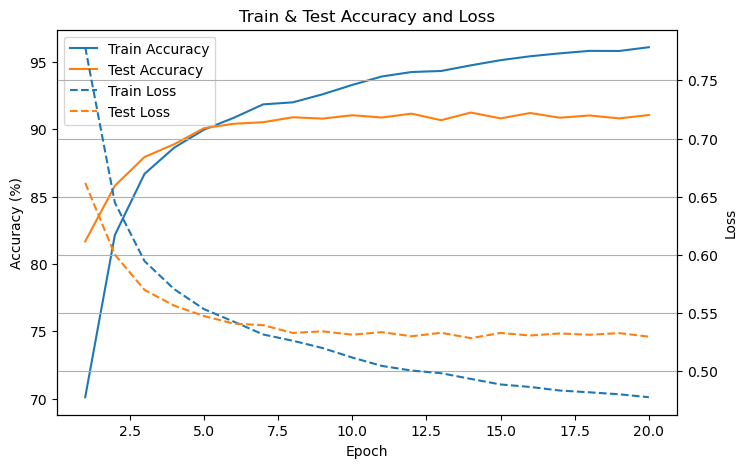

In [5]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt

# PATHS
DATA_DIR = "/home/student/Downloads/copycat_fer_project/npdd_sl"
TEST_DIR = "/home/student/Downloads/copycat_fer_project/FER2013_3 Class/test"
SAVE_PATH = "/home/student/Downloads/copycat_fer_project/copycat_model.pth"

# CONFIG
BATCH_SIZE = 128   
EPOCHS = 30
LR = 5e-5          
NUM_CLASSES = 3
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("Using device:", DEVICE)

# TRANSFORM (UNCHANGED)
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

# DATA
full_ds = datasets.ImageFolder(DATA_DIR, transform=transform)

train_size = int(0.8 * len(full_ds))
test_size  = len(full_ds) - train_size

train_ds, npdd_test_ds = random_split(full_ds, [train_size, test_size])

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
npdd_test_loader = DataLoader(npdd_test_ds, batch_size=BATCH_SIZE, shuffle=False)

# FER TEST
fer_test_ds = datasets.ImageFolder(TEST_DIR, transform=transform)
fer_test_loader = DataLoader(fer_test_ds, batch_size=BATCH_SIZE, shuffle=False)

# MODEL
model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)

model.classifier = nn.Sequential(
    nn.Dropout(0.6),   
    nn.Linear(model.last_channel, NUM_CLASSES)
)

model = model.to(DEVICE)

# Freeze backbone
for param in model.features.parameters():
    param.requires_grad = False

# Unfreeze last layers
for param in model.features[-1].parameters():
    param.requires_grad = True
for param in model.features[-2].parameters():
    param.requires_grad = True
for param in model.features[-3].parameters():
    param.requires_grad = True

for param in model.classifier.parameters():
    param.requires_grad = True

# LOSS 
criterion = nn.CrossEntropyLoss(label_smoothing=0.15)

# OPTIMIZER 
optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR,
    weight_decay=5e-4   
)

# SCHEDULER
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

# EARLY STOPPING
best_val_loss = float("inf")
patience = 6
counter = 0
delta = 0.001

train_acc_list = []
test_acc_list = []
train_loss_list = []
test_loss_list = []
fer_acc_list = []

# TRAINING
for epoch in range(EPOCHS):

    # TRAIN
    model.train()
    correct, total = 0, 0
    running_loss = 0

    for x, y in train_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)

        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        pred = out.argmax(1)
        correct += (pred == y).sum().item()
        total += y.size(0)

    train_acc = 100 * correct / total
    train_loss = running_loss / len(train_loader)

    train_acc_list.append(train_acc)
    train_loss_list.append(train_loss)

    # NPDD TEST
    model.eval()
    test_loss = 0
    test_correct, test_total = 0, 0

    with torch.no_grad():
        for x, y in npdd_test_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)

            out = model(x)
            loss = criterion(out, y)

            test_loss += loss.item()

            pred = out.argmax(1)
            test_correct += (pred == y).sum().item()
            test_total += y.size(0)

    test_loss /= len(npdd_test_loader)
    test_acc = 100 * test_correct / test_total

    test_acc_list.append(test_acc)
    test_loss_list.append(test_loss)

    # FER TEST EVERY EPOCH
    fer_correct, fer_total = 0, 0

    with torch.no_grad():
        for x, y in fer_test_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)

            out = model(x)
            pred = out.argmax(1)

            fer_correct += (pred == y).sum().item()
            fer_total += y.size(0)

    fer_acc = 100 * fer_correct / fer_total
    fer_acc_list.append(fer_acc)

    print(f"Epoch {epoch+1}: "
          f"Train={train_acc:.2f}% | NPDD={test_acc:.2f}% | FER={fer_acc:.2f}% || "
          f"TL={train_loss:.3f} | TeL={test_loss:.3f}")

    # EARLY STOPPING
    if test_loss < best_val_loss - delta:
        best_val_loss = test_loss
        counter = 0
        torch.save(model.state_dict(), SAVE_PATH)
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping triggered")
            break

    scheduler.step()

print("Best model saved.")

print("\n FINAL FER TEST ACCURACY:", round(fer_acc_list[-1],2), "%")

# GRAPH
epochs_range = range(1, len(train_acc_list)+1)

fig, ax1 = plt.subplots(figsize=(8,5))

ax1.set_xlabel("Epoch")
ax1.set_ylabel("Accuracy (%)")
ax1.plot(epochs_range, train_acc_list, label="Train Accuracy")
ax1.plot(epochs_range, test_acc_list, label="Test Accuracy")

ax2 = ax1.twinx()
ax2.set_ylabel("Loss")
ax2.plot(epochs_range, train_loss_list, linestyle='--', label="Train Loss")
ax2.plot(epochs_range, test_loss_list, linestyle='--', label="Test Loss")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(lines1 + lines2, labels1 + labels2, loc="best")

plt.title("Train & Test Accuracy and Loss")
plt.grid(True)
plt.show()

In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt

# PATHS
DATA_DIR = "/home/student/Downloads/copycat_fer_project/npdd_sl"
TEST_DIR = "/home/student/Downloads/copycat_fer_project/FER2013_3 Class/test"
SAVE_PATH = "/home/student/Downloads/copycat_fer_project/copycat_model.pth"

# CONFIG
BATCH_SIZE = 128
EPOCHS = 50
LR = 1e-5   
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("Using device:", DEVICE)

# TRANSFORM (same)
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

# DATA
full_ds = datasets.ImageFolder(DATA_DIR, transform=transform)

train_size = int(0.8 * len(full_ds))
test_size  = len(full_ds) - train_size

train_ds, npdd_test_ds = random_split(full_ds, [train_size, test_size])

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
npdd_test_loader = DataLoader(npdd_test_ds, batch_size=BATCH_SIZE, shuffle=False)

fer_test_ds = datasets.ImageFolder(TEST_DIR, transform=transform)
fer_test_loader = DataLoader(fer_test_ds, batch_size=BATCH_SIZE, shuffle=False)

# MODEL
model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)

model.classifier = nn.Sequential(
    nn.Dropout(0.6),
    nn.Linear(model.last_channel, 3)
)

model = model.to(DEVICE)

#  UNFREEZE MORE
for param in model.features.parameters():
    param.requires_grad = False

for i in range(-8, 0):   #  deeper tuning
    for param in model.features[i].parameters():
        param.requires_grad = True

for param in model.classifier.parameters():
    param.requires_grad = True

# LOSS
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

# OPTIMIZER
optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR,
    weight_decay=5e-4
)

# SCHEDULER
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

# EARLY STOP
best_loss = float("inf")
patience = 10
counter = 0

train_acc_list, test_acc_list = [], []
train_loss_list, test_loss_list = [],[]
fer_acc_list = []

# TRAIN LOOP
for epoch in range(EPOCHS):

    model.train()
    correct, total, running_loss = 0, 0, 0

    for x, y in train_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)

        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        pred = out.argmax(1)
        correct += (pred == y).sum().item()
        total += y.size(0)

    train_acc = 100 * correct / total
    train_loss = running_loss / len(train_loader)

    train_acc_list.append(train_acc)
    train_loss_list.append(train_loss)

    # NPDD TEST
    model.eval()
    test_loss, test_correct, test_total = 0, 0, 0

    with torch.no_grad():
        for x, y in npdd_test_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)

            out = model(x)
            loss = criterion(out, y)

            test_loss += loss.item()
            pred = out.argmax(1)

            test_correct += (pred == y).sum().item()
            test_total += y.size(0)

    test_loss /= len(npdd_test_loader)
    test_acc = 100 * test_correct / test_total

    test_acc_list.append(test_acc)
    test_loss_list.append(test_loss)

    # FER TEST
    fer_correct, fer_total = 0, 0

    with torch.no_grad():
        for x, y in fer_test_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)

            pred = model(x).argmax(1)
            fer_correct += (pred == y).sum().item()
            fer_total += y.size(0)

    fer_acc = 100 * fer_correct / fer_total
    fer_acc_list.append(fer_acc)

    print(f"Epoch {epoch+1}: "
          f"Train={train_acc:.2f}% | NPDD={test_acc:.2f}% | FER={fer_acc:.2f}% || "
          f"TL={train_loss:.3f} | TeL={test_loss:.3f}")

    # EARLY STOP
    if test_loss < best_loss:
        best_loss = test_loss
        counter = 0
        torch.save(model.state_dict(), SAVE_PATH)
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping triggered")
            break

    scheduler.step()

print("\nFINAL FER ACC:", round(fer_acc_list[-1],2), "%")

#  GRAPH 
epochs_range = range(1, len(train_acc_list)+1)

fig, ax1 = plt.subplots(figsize=(8,5))

ax1.set_xlabel("Epoch")
ax1.set_ylabel("Accuracy (%)")
ax1.plot(epochs_range, train_acc_list, label="Train Accuracy")
ax1.plot(epochs_range, test_acc_list, label="Test Accuracy")

ax2 = ax1.twinx()
ax2.set_ylabel("Loss")
ax2.plot(epochs_range, train_loss_list, linestyle='--', label="Train Loss")
ax2.plot(epochs_range, test_loss_list, linestyle='--', label="Test Loss")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(lines1 + lines2, labels1 + labels2, loc="best")

plt.title("Train & Test Accuracy and Loss")
plt.grid(True)
plt.show()

Using device: cuda
Epoch 1: Train=57.15% | NPDD=68.92% | FER=29.34% || TL=0.944 | TeL=0.785
Epoch 2: Train=69.38% | NPDD=74.28% | FER=29.45% || TL=0.733 | TeL=0.670
Epoch 3: Train=76.28% | NPDD=81.83% | FER=31.97% || TL=0.653 | TeL=0.604
Epoch 4: Train=81.42% | NPDD=84.97% | FER=34.79% || TL=0.595 | TeL=0.551
Epoch 5: Train=85.37% | NPDD=87.37% | FER=37.05% || TL=0.543 | TeL=0.510
Epoch 6: Train=87.88% | NPDD=89.40% | FER=38.93% || TL=0.504 | TeL=0.479
Epoch 7: Train=89.64% | NPDD=90.78% | FER=39.92% || TL=0.478 | TeL=0.457
Epoch 8: Train=91.25% | NPDD=91.28% | FER=39.77% || TL=0.459 | TeL=0.447
Epoch 9: Train=91.92% | NPDD=91.80% | FER=41.73% || TL=0.446 | TeL=0.443
Epoch 10: Train=92.82% | NPDD=92.57% | FER=41.91% || TL=0.434 | TeL=0.428
Epoch 11: Train=93.15% | NPDD=92.73% | FER=42.74% || TL=0.426 | TeL=0.428
Epoch 12: Train=93.65% | NPDD=93.23% | FER=43.46% || TL=0.418 | TeL=0.421
Epoch 13: Train=94.11% | NPDD=93.35% | FER=43.58% || TL=0.413 | TeL=0.418
Epoch 14: Train=94.42% | NPD